# Mappeoppgave - Del 2.1, IIRA2001 - Høst 2023

# Korrelasjon styringsrente og valutakurs

For å undersøke korrealasjonen mellom kronekursen og styringsrenten, vil jeg hente kronekursen målt mot Euro fra Yfinance, og informasjon om styringsrenten fra SSB. Dagens situasjon med høy inflasjon har i stor grad bakgrunn i importinflasjon som følge av svak kornekurs. Følgelig er det håp for at renteøkningen kan styrke kronen, gjennom redusert eller styrket rentedifferanse mot utland. Har rentehevingene gitt ønsket effekt med hensyn på kronekursen, og hvordan er den siste tidens korrelasjon?

In [2]:
import yfinance as yf
import pandas as pd

def månedlige_valutakurser(symbol, antall_år = 5):
    
    sluttdato = pd.to_datetime('2023-09-30')
    startdato = sluttdato - pd.DateOffset(years = antall_år)
    
    valutapar = yf.Ticker(symbol)
    data = valutapar.history(start = startdato, end = sluttdato)
    
    månedlige_data = data.resample('M').last()
    
    return pd.DataFrame({'Close': månedlige_data['Close']})

symbol = 'EURNOK=X'

valutakurser_df = månedlige_valutakurser(symbol, antall_år = 5)

valutakurser_df

,Close
Date,
2018-10-31 00:00:00+00:00,9.53950
2018-11-30 00:00:00+00:00,9.72130
2018-12-31 00:00:00+00:00,9.96080
2019-01-31 00:00:00+00:00,9.66860
2019-02-28 00:00:00+00:00,9.72319
2019-03-31 00:00:00+00:00,9.69620
2019-04-30 00:00:00+01:00,9.67690
2019-05-31 00:00:00+01:00,9.76837
2019-06-30 00:00:00+01:00,9.67580


In [3]:
SSBENC = "ISO-8859-1"

rente_df = pd.read_csv("10701_20231109-115624.csv", sep="\t",
                    encoding = SSBENC)

rente_df.columns = ['Rentetype', 'Måned', 'Styringsrente']

rente_df




,Rentetype,Måned,Styringsrente
0,Norges Banks foliorente (styringsrenten),2018M10,0.75
1,Norges Banks foliorente (styringsrenten),2018M11,0.75
2,Norges Banks foliorente (styringsrenten),2018M12,0.75
3,Norges Banks foliorente (styringsrenten),2019M01,0.75
4,Norges Banks foliorente (styringsrenten),2019M02,0.75
5,Norges Banks foliorente (styringsrenten),2019M03,1.00
6,Norges Banks foliorente (styringsrenten),2019M04,1.00
7,Norges Banks foliorente (styringsrenten),2019M05,1.00
8,Norges Banks foliorente (styringsrenten),2019M06,1.25
9,Norges Banks foliorente (styringsrenten),2019M07,1.25


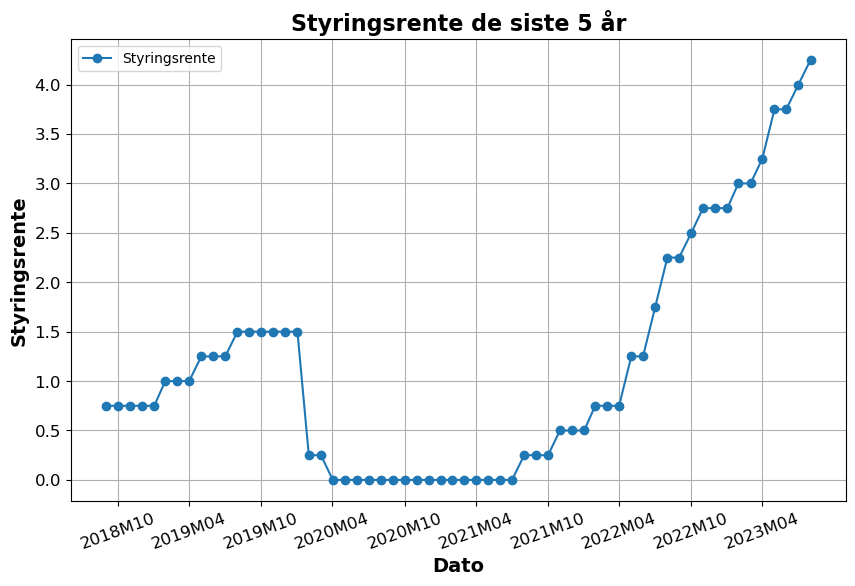

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

rente_df['Måned'] = pd.to_datetime(rente_df['Måned'], format='%YM%m')

plt.figure(figsize=(10, 6))
plt.plot(rente_df['Måned'], rente_df['Styringsrente'], label='Styringsrente', marker='o')

halvår = pd.date_range(start=rente_df['Måned'].min(), end=rente_df['Måned'].max(), freq='6M')
halvår_format = halvår.strftime('%YM%m')

plt.xticks(halvår, halvår_format, rotation=20, ha='center', fontsize=12)

plt.yticks(np.arange(min(rente_df['Styringsrente']), max(rente_df['Styringsrente']), 0.5), fontsize=12)

plt.xlabel('Dato', fontweight='bold', fontsize=14)
plt.ylabel('Styringsrente', fontweight='bold', fontsize=14)
plt.title('Styringsrente de siste 5 år', fontweight='bold', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

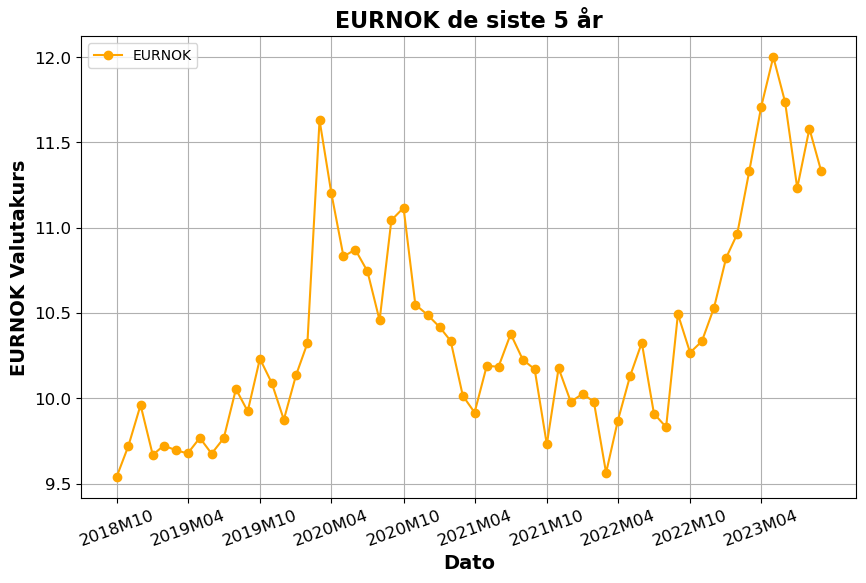

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(valutakurser_df.index, valutakurser_df['Close'], label='EURNOK', marker='o', color='orange')

plt.xticks(halvår, halvår_format, rotation=20, fontsize=12, ha='center')
plt.yticks(fontsize=12)

plt.xlabel('Dato', fontweight='bold', fontsize=14)
plt.ylabel('EURNOK Valutakurs', fontweight='bold', fontsize=14)
plt.title('EURNOK de siste 5 år', fontweight='bold', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

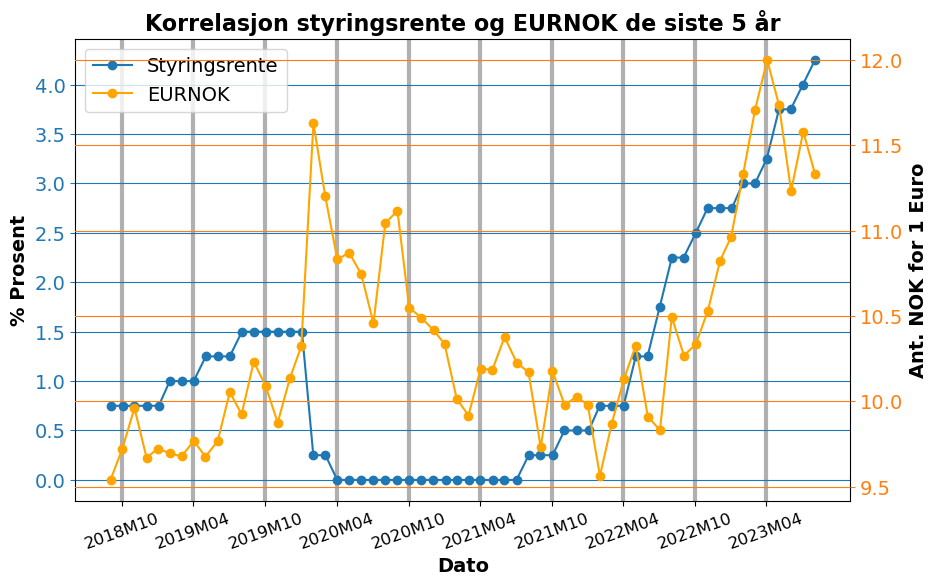

In [6]:
from matplotlib.ticker import MultipleLocator

figur=plt.figure(figsize=(10,6))

x=figur.add_subplot(111, label="1")
x2=figur.add_subplot(111, label="2", frame_on=False)

linje, = x.plot(rente_df['Måned'], rente_df['Styringsrente'], label='Styringsrente', marker='o')
x.set_xlabel("Dato", fontweight='bold', fontsize=14)
x.set_ylabel("% Prosent", fontweight='bold', fontsize=14)
x.tick_params(axis='x')
x.tick_params(axis='y', colors="C0")

linje2, = x2.plot(valutakurser_df.index, valutakurser_df['Close'], label='EURNOK', marker='o', color='orange')
x2.yaxis.tick_right()
x2.set_ylabel('Ant. NOK for 1 Euro', fontweight='bold', fontsize=14)       
x2.yaxis.set_label_position('right') 
x2.tick_params(axis='y', colors="C1")

plt.title('Korrelasjon styringsrente og EURNOK de siste 5 år', fontweight='bold', fontsize=16)

x.grid(True, axis='y', color='C0')
x.grid(True, axis='x', linewidth=3)
x2.grid(True, color='C1')

x.tick_params(axis='x', labelsize=14)
x.tick_params(axis='y', labelsize=14)
x2.tick_params(axis='y', labelsize=14)
x2.set_xticks([])

x.yaxis.set_major_locator(MultipleLocator(0.5))
x.set_xticks(halvår)
x.set_xticklabels(halvår_format, rotation=20, fontsize=12, ha='center')
x.legend(handles=[linje, linje2], loc='upper left', fontsize=14)

plt.show()

Benytter subplots for å sammenligne og underøke korrelasjonen mellom styringsrente og kronekursen. Den "teoretiske" korrelasjonen vi ser etter er økt styringsrente->styrket krone. Altså styringsrenten går opp, og Euroen målt i kroner går ned.

Fra perioden 2018M10 til starten av 2020 stiger både rentenivået og EURNOK (kronen svakere). Rentehevingene "holder igjen" EURNOK og hindrer Euroen fra å skyte til værs i forhold til kronen. Dette var også en periode hvor det var forventet en nedkjølning i økonomien, og potensiell resesjon, helt til pandemien brøt frem. Når pandemien kommer tvinges Norges Bank til å kraftig sette ned renta for å stimulere norsk økonomi. Imidlertid var nok pandemiens uttallige variabler samt med på å svekke kronen akkurat i øyeblikket, så i hvilken grad det var reduksjon i styringsrente er vanskelig å si. Dette var trolig helt nødvendig på tidspunktet, men utsatt bare den lenge ventede korreksjonen og nedkjølningen. Kronen styrker seg noe i løpet av perioden selv med 0 i styringsrente frem til starten av 2022. Det er svært mange påvirkninger for en valutakurs, eksempelvis eksport/import og oljepris, slik at dette viser i det minste en begrenset korrelasjon mellom styringsrente og kronekursen. Utover 2022 og 2023 blir det virkelig stygt for kronekursen, dette bidrar til økt inflasjon og tvinger styringsrenten opp. Selv om trenden er stigende for de begge, kan vi i hele diagrammet se tilfeller av hvor styringsrenten heves, og kronekursen styrkes en liten periode før den svekkes igjen. Det er ikke lett å formidle godt gjennom diagrammet, men med stor sannsynlighet ville kronekursen vært enda mye svakere, dersom styringsrenten ikke hadde blitt hevet like mye. I slutten av perioden ser vi kronekursen ha styrket seg noe, siden 2023M04. Det mest interessante er som jeg var inne på hvordan kronekursen beveger seg, når styringsrenten endres. Men noe teori i bakhodet kan vi se en viss korrelasjon. Men om vi skal legge all teori til sides og se på de "harde" tallene alene, kan man ikke slå fast en definitiv korrelasjon (høyere rente, sterkere krone), i alle fall ikke i perioden som jeg tar for meg her. Dette må begrunnes i de mange ulike påvirkninger og variabler som finnes i Makroøkonomien. Dermed lander vi på de begrensede tilfellene som fremkommer av diagrammet. Ved oppgang både før og etter pandemitiden har det som nevnt ulmet til eller vært konjukturnedgang, slik at også mange faktorer kan spille inn på at de begge beveger seg nokså likt i henhold til grafene. Også som nevnt kan importinflasjon være en direkte årsak til oppgang av styringsrente, slik at det der finnes en indirekte sammenheng. Samt kan valutakursen vi måler kronen i gi noe varierende bilder, slik at om jeg istedenfor hadde valgt dollar, kunne det sett litt annerledes ut.

Mtp. korrelasjon er den mest riktige konklusjonen: begrenset. Dette med bakgrunn i de uttallige andre påvrikninger og variabler. Samt basert på hva vi ser av graf.

Til spørsmålet om kronen har styrket seg som håpet på bakgrunn av økt styringsrente kan vi nok i stor grad si nei. Selv med de mange renteøkningene den siste tiden, har EUROEN steget målt i NOK gang på gang. Dette bildet underbygger de mange påstander i nyhetene, om mørke tider for kronen. Når rentedifferansen mot utland ikke er nok til å i alle fall til en viss grad styrke eller stabilisere kronen, forteller det i det minste at der er andre alvorlige faktorer som betyr dårlig nytt for den norske kronen.

In [7]:
kurser =[]
for i in range(60):
    kurser.append(valutakurser_df.iloc[i]["Close"])
    
rente_df.insert(2, "Valutakurser", kurser)
    
rente_df

print(rente_df["Styringsrente"].corr(rente_df["Valutakurser"]))

0.47201395159406195


Vi ser en positiv lineær korrelasjon på 0,47. Vi kan ta med oss fra dette at det definitivt finnes sammenhenger, men som det så ofte gjør i makroøkonomi. I tillegg til tidligere nevnte øvrige påvirkninger, er det vanskelig å legge så mye mer i bare dette. Når det gjelder spørsmålet om ønsket effekt av rentehevinger, bidrar dette heller mot det dystre bildet, en svak norsk krone med minimal påvirkning fra rentedifferanse. Vi ønsker altså med dette å ikke se en positiv korrelasjon. Nedenfor vises også korrelasjon i scatter plot.

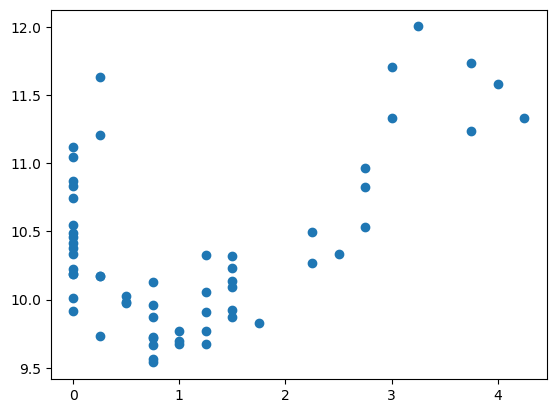

In [8]:
plt.scatter(rente_df["Styringsrente"], rente_df["Valutakurser"])